First 5 rows:
   StudentID  Attendance  AssignmentScore  Participation  ExamScore
0        101          89               70              5         74
1        102          52               55              5         61
2        103          83               36              5         59
3        104          70               43              2         48
4        105          60               41              2         40

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   StudentID        50 non-null     int64
 1   Attendance       50 non-null     int64
 2   AssignmentScore  50 non-null     int64
 3   Participation    50 non-null     int64
 4   ExamScore        50 non-null     int64
dtypes: int64(5)
memory usage: 2.1 KB
None

Missing Values:
StudentID          0
Attendance         0
AssignmentScore    0
Participation      0
Ex

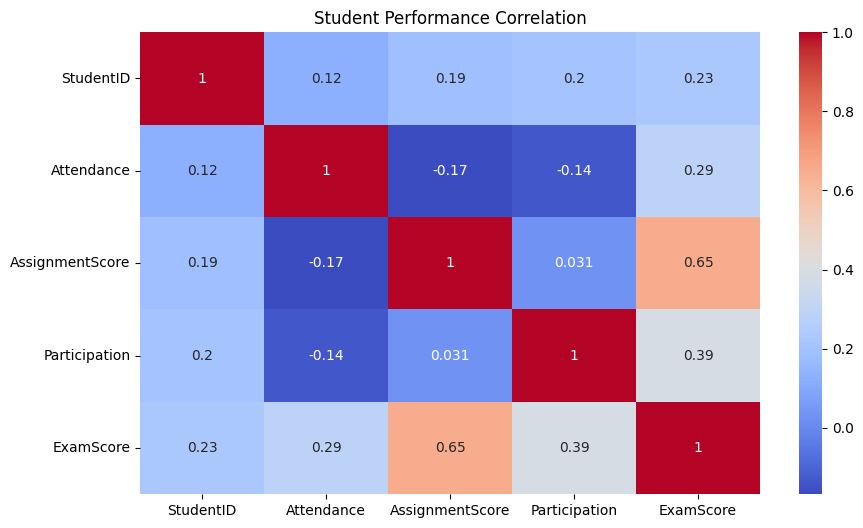

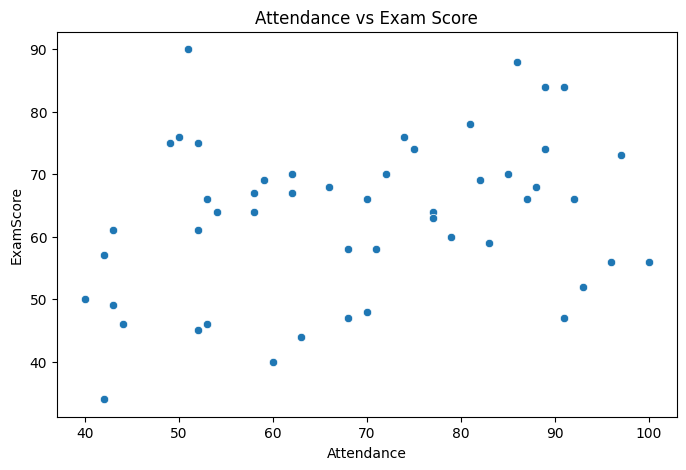

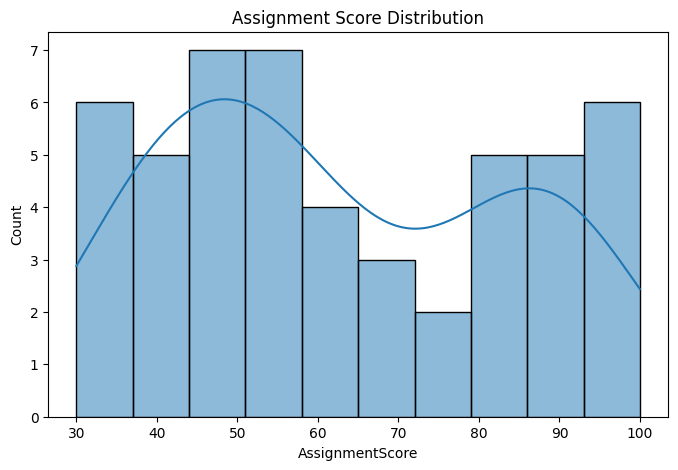


Student Risk Categories:
    StudentID  ExamScore   RiskStatus
0         101         74     Low Risk
1         102         61     Low Risk
2         103         59  Medium Risk
3         104         48  Medium Risk
4         105         40  Medium Risk
5         106         46  Medium Risk
6         107         46  Medium Risk
7         108         75     Low Risk
8         109         69     Low Risk
9         110         66     Low Risk
10        111         66     Low Risk
11        112         58  Medium Risk
12        113         47  Medium Risk
13        114         70     Low Risk
14        115         70     Low Risk
15        116         50  Medium Risk
16        117         44  Medium Risk
17        118         64     Low Risk
18        119         34    High Risk
19        120         67     Low Risk
20        121         78     Low Risk
21        122         84     Low Risk
22        123         75     Low Risk
23        124         45  Medium Risk
24        125         68

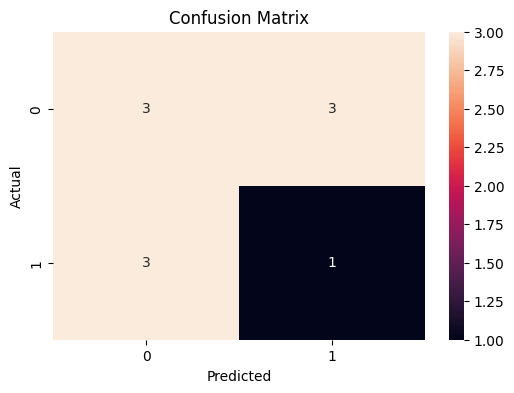

Total Students: 50
Average Attendance: 68.78
Average Assignment Score: 62.54
Average Exam Score: 63.16

Risk Student Count:
RiskStatus
1    32
2    17
0     1
Name: count, dtype: int64

Project Completed Successfully


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("student_data.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert categorical variables if present
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("\nCleaned Data:")
print(df.head())

# Correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Student Performance Correlation")
plt.show()


# Attendance vs Exam Score
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Attendance',
    y='ExamScore',
    data=df
)

plt.title("Attendance vs Exam Score")
plt.show()


# Assignment Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['AssignmentScore'],
             bins=10,
             kde=True)

plt.title("Assignment Score Distribution")
plt.show()

# Create risk category

def risk_level(score):

    if score < 40:
        return "High Risk"

    elif score < 60:
        return "Medium Risk"

    else:
        return "Low Risk"


df['RiskStatus'] = df['ExamScore'].apply(risk_level)

print("\nStudent Risk Categories:")
print(df[['StudentID','ExamScore','RiskStatus']])


# Convert target variable
df['RiskStatus']=label_encoder.fit_transform(df['RiskStatus'])

X = df[['Attendance',
        'AssignmentScore',
        'Participation']]

y = df['RiskStatus']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test,y_pred)

print("\nAccuracy:",accuracy)

print("\nClassification Report")
print(classification_report(y_test,y_pred))

# Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(confusion_matrix(y_test,y_pred),
            annot=True,
            fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("Total Students:",len(df))

print("Average Attendance:",
      round(df['Attendance'].mean(),2))

print("Average Assignment Score:",
      round(df['AssignmentScore'].mean(),2))

print("Average Exam Score:",
      round(df['ExamScore'].mean(),2))

print("\nRisk Student Count:")

print(df['RiskStatus'].value_counts())

print("\nProject Completed Successfully")